# Limpieza e imputación del panel ambiental 2024

1. **Objetivo del notebook**

- Limpiar el panel ambiental e imputar sus valores faltantes de altitud y NDVI.

2. **Decisiones metodológicas**

- Aplicar KNN por celda para altitud y por celda-semana para NDVI; seleccionar `k` con validación cruzada.
- Evitar fuga temporal en NDVI mediante particiones agrupadas por `grid_id`.
- Usar geometría sólo durante la imputación y guardar las banderas en el panel de control.

3. **Fuentes**

- `data/interim/environment/environment_grid_week_2024_raw.parquet`, generado por `01`.
- `data/processed/environment/grid_geometry.parquet`, generado por `01`.
- `data/interim/environment/quality_check_environment_grid_week_2024_raw.parquet`, generado por `01`.

4. **Productos**

- `data/processed/environment/environment_grid_week_2024_clean.parquet`.
- `data/interim/environment/quality_check_environment_grid_week_2024_raw.parquet`, actualizado con banderas de imputación.
- Diagnósticos KNN en `data/diagnostics` y figuras en `outputs/figures/knn_experiments`.


La imputación usa `KNeighborsRegressor`. La geometría se incorpora temporalmente y no se guarda en el panel limpio.

> **Advertencia:** imputar NDVI con variables climáticas puede inducir correlaciones entre predictores. Debe evaluarse su sensibilidad antes del modelamiento.

In [1]:
# Librerías para datos espaciales, modelamiento KNN, validación y gráficos
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import HTML, display


# Búsqueda de la raíz para importar rutas y funciones comunes desde src
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

# Rutas centralizadas de entradas, productos, diagnósticos y figuras
from src.paths import (
    DIAGNOSTICS_KNN_ALTITUDE_PATH,
    DIAGNOSTICS_KNN_NDVI_PATH,
    ENVIRONMENT_GRID_WEEK_CLEAN_PATH,
    ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH,
    ENVIRONMENT_GRID_WEEK_RAW_PATH,
    FIGURES_DIR,
    GRID_GEOMETRY_PATH,
)

# Parámetros reproducibles para selección de vecinos y validación cruzada
RANDOM_STATE = 42
K_VALUES_LIMIT = 30
CV_FOLDS = 5
METRIC_CRS = "EPSG:32719"


## Carga y visualización del panel raw

Se muestran diez filas, se une la geometría y se calculan `epiweek_sin` y `epiweek_cos` para representar la estacionalidad.

In [2]:
# Carga y vista completa de diez filas; el contenedor permite desplazamiento horizontal
panel_raw = pd.read_parquet(ENVIRONMENT_GRID_WEEK_RAW_PATH)
display(HTML("<div style='overflow-x:auto'>" + panel_raw.head(10).to_html(index=False, max_cols=None) + "</div>"))



grid_id,year,epiweek,tmean_c,tmin_c,tmax_c,alt_min,alt_mean,alt_max,rh_mean,rh_min,rh_max,tp_sum,koppen_fin,population,ndvi_media_bisemanal,ndvi_maximo_bisemanal,ndvi_minimo_bisemanal,ndvi_desvest_bisemanal
0,2024,1,21.209301,19.992899,22.276896,25.0,33.596774,43.0,74.356583,71.468781,76.885185,0.016606,BWh,0.0,0.050019,0.081831,-0.021624,0.004055
0,2024,2,22.054096,21.573660,22.765982,25.0,33.596774,43.0,73.982315,71.317276,76.284805,0.011030,BWh,0.0,0.048979,0.080882,-0.004966,0.003381
0,2024,3,22.568083,22.038534,23.052988,25.0,33.596774,43.0,75.665398,72.660240,78.163437,0.068585,BWh,0.0,0.047940,0.079934,0.011691,0.002707
0,2024,4,23.774378,23.398520,24.111084,25.0,33.596774,43.0,72.535446,70.525070,74.601913,0.008243,BWh,0.0,0.043426,0.070744,0.004822,0.001353
0,2024,5,22.861515,22.499634,23.158884,25.0,33.596774,43.0,73.460915,72.232567,74.605240,0.005395,BWh,0.0,0.038912,0.061555,-0.002047,0.000000
0,2024,6,25.018829,24.110687,25.648270,25.0,33.596774,43.0,71.713272,67.142258,77.242050,0.005812,BWh,0.0,NaN,NaN,NaN,NaN
0,2024,7,23.730053,23.066925,24.236368,25.0,33.596774,43.0,75.282051,71.676620,81.074158,0.052671,BWh,0.0,NaN,NaN,NaN,NaN
0,2024,8,24.646017,23.532104,25.408484,25.0,33.596774,43.0,76.529297,72.132515,81.423096,0.047258,BWh,0.0,NaN,NaN,NaN,NaN
0,2024,9,23.541357,22.868347,24.530279,25.0,33.596774,43.0,75.064690,73.228439,77.841995,0.171275,BWh,0.0,0.027595,0.062425,-0.020239,0.000000
0,2024,10,23.356249,22.439676,24.117676,25.0,33.596774,43.0,74.060120,72.234764,77.018234,0.004876,BWh,0.0,0.037177,0.069368,-0.017917,0.003663


In [3]:
# Incorpora temporalmente la geometría necesaria para la imputación espacial
grid_geometry = gpd.read_parquet(GRID_GEOMETRY_PATH)
gdf = gpd.GeoDataFrame(panel_raw.merge(grid_geometry[["grid_id", "geometry"]], on="grid_id", how="left", validate="many_to_one"), geometry="geometry", crs=grid_geometry.crs)

# Reproyección a coordenadas métricas para calcular centroides y distancias en metros
gdf_metric = gdf.to_crs(METRIC_CRS)
centroids = gdf_metric.geometry.centroid
gdf["centroid_x_m"] = centroids.x.to_numpy()
gdf["centroid_y_m"] = centroids.y.to_numpy()
# Representación circular de la semana: SE52 queda próxima a SE1
gdf["epiweek_sin"] = np.sin(2 * np.pi * gdf["epiweek"].astype(float) / 52.0)
gdf["epiweek_cos"] = np.cos(2 * np.pi * gdf["epiweek"].astype(float) / 52.0)
print(f"Centroides calculados en {METRIC_CRS}; sólo se usarán durante diagnóstico e imputación.")


Centroides calculados en EPSG:32719; sólo se usarán durante diagnóstico e imputación.


## Preparación de predictores

Se definen objetivos, banderas y predictores para altitud y NDVI. La altitud se resume por `grid_id`; NDVI incorpora posición, clima, población, Köppen y estacionalidad circular.

In [4]:
# Variables objetivo y banderas que documentarán las imputaciones realizadas
ALTITUDE_COLUMNS = ["alt_min", "alt_mean", "alt_max"]
NDVI_COLUMNS = ["ndvi_media_bisemanal", "ndvi_maximo_bisemanal", "ndvi_minimo_bisemanal", "ndvi_desvest_bisemanal"]
NDVI_IMPUTATION_FLAGS = ["ndvi_media_bisemanal_imputed", "ndvi_maximo_bisemanal_imputed", "ndvi_minimo_bisemanal_imputed", "ndvi_desvest_bisemanal_imputed"]
# Predictores definidos por el esquema canónico generado en 01
CLIMATE_COLUMNS = ["tmean_c", "tmin_c", "tmax_c", "rh_mean", "rh_min", "rh_max", "tp_sum"]
POPULATION_COLUMNS = ["population"]
CONTEXT_COLUMNS = ["koppen_fin"]

# Recupera el primer valor observado de una variable estática dentro de cada grid_id
def first_non_null(series):
    values = series.dropna()
    return values.iloc[0] if not values.empty else np.nan

# La altitud se imputa una vez por celda porque no varía entre semanas
altitude_by_grid = gdf.groupby("grid_id", as_index=False).agg({column: first_non_null for column in ALTITUDE_COLUMNS})
for column in ALTITUDE_COLUMNS:
    values_per_grid = gdf.groupby("grid_id")[column].nunique(dropna=True)
    if values_per_grid.gt(1).any():
        raise ValueError(f"{column} no es estática por grid_id.")

# Selección explícita de predictores para los modelos de altitud y NDVI
ALTITUDE_NUMERIC_PREDICTORS = ["centroid_x_m", "centroid_y_m", *POPULATION_COLUMNS[:1]]
ALTITUDE_CATEGORICAL_PREDICTORS = CONTEXT_COLUMNS[:1]
NDVI_NUMERIC_PREDICTORS = ["centroid_x_m", "centroid_y_m", "epiweek_sin", "epiweek_cos", *CLIMATE_COLUMNS, "alt_mean", *POPULATION_COLUMNS[:1]]
NDVI_CATEGORICAL_PREDICTORS = CONTEXT_COLUMNS[:1]
print("Predictores altitud numéricos:", ALTITUDE_NUMERIC_PREDICTORS)
print("Predictores altitud categóricos:", ALTITUDE_CATEGORICAL_PREDICTORS)
print("Predictores NDVI numéricos:", NDVI_NUMERIC_PREDICTORS)
print("Predictores NDVI categóricos:", NDVI_CATEGORICAL_PREDICTORS)


Predictores altitud numéricos: ['centroid_x_m', 'centroid_y_m', 'population']
Predictores altitud categóricos: ['koppen_fin']
Predictores NDVI numéricos: ['centroid_x_m', 'centroid_y_m', 'epiweek_sin', 'epiweek_cos', 'tmean_c', 'tmin_c', 'tmax_c', 'rh_mean', 'rh_min', 'rh_max', 'tp_sum', 'alt_mean', 'population']
Predictores NDVI categóricos: ['koppen_fin']


## Imputación KNN de altitud

La altitud se modela una vez por `grid_id`. El método 1 compara el RMSE para distintos `k`; el método 4 compara R² de entrenamiento y validación. Entre los `k` dentro de un error estándar del RMSE mínimo se elige la menor brecha de R².

### 1. Método 1: desempeño según `k`

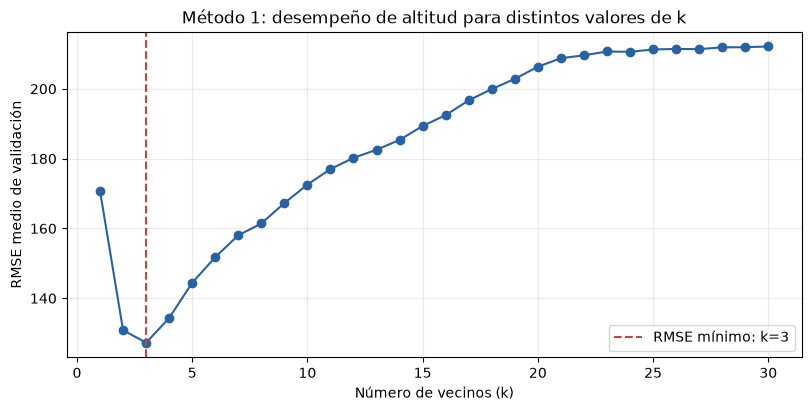

,k,validation_rmse,validation_rmse_se,validation_r2
0,1,170.706787,3.044189,0.987125
1,2,130.858587,3.532253,0.992434
2,3,127.269757,6.183282,0.992853
3,4,134.330749,8.581374,0.992003
4,5,144.428438,9.682236,0.990742
5,6,151.781985,11.215923,0.989748
6,7,158.034350,12.009589,0.988875
7,8,161.423500,12.572685,0.988374
8,9,167.266856,13.308775,0.987508
9,10,172.548061,13.481703,0.986715


In [5]:
# Preprocesamiento común: estandariza variables numéricas y codifica categorías
def make_preprocessor(numeric_features, categorical_features):
    transformers = []
    if numeric_features:
        transformers.append(("num", StandardScaler(), numeric_features))
    if categorical_features:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features))
    return ColumnTransformer(transformers=transformers)

# Valores de k factibles según el tamaño mínimo del conjunto de entrenamiento
def candidate_k_values(n_rows, n_splits):
    min_train_rows = n_rows - int(np.ceil(n_rows / n_splits)) # celdas de entrenamiento
    return list(range(1, max(1, min(K_VALUES_LIMIT, min_train_rows)) + 1)) # 1 a K_VALUES_LIMIT o al tamaño de entrenamiento

# Evalúa cada k mediante validación cruzada y resume su desempeño
def evaluate_kfold(X, y, numeric_features, categorical_features, k_values, splitter, groups=None):
    rows = []
    split_args = (X, y, groups) if groups is not None else (X, y)
    for k in k_values:
        fold_rows = []
        for train_idx, valid_idx in splitter.split(*split_args):
            if groups is not None and set(groups.iloc[train_idx]) & set(groups.iloc[valid_idx]):
                raise ValueError("GroupKFold mezcló grid_id entre train y validación.")
            # Cada partición ajusta el preprocesamiento solo con los datos de entrenamiento
            model = Pipeline([("preprocess", make_preprocessor(numeric_features, categorical_features)), ("knn", KNeighborsRegressor(n_neighbors=k))])
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            prediction = model.predict(X.iloc[valid_idx])
            fold_rows.append({"train_r2": model.score(X.iloc[train_idx], y.iloc[train_idx]), "validation_r2": model.score(X.iloc[valid_idx], y.iloc[valid_idx]), "validation_rmse": np.sqrt(mean_squared_error(y.iloc[valid_idx], prediction))})
        fold_scores = pd.DataFrame(fold_rows)
        rows.append({
            "k": k,
            "train_r2": fold_scores["train_r2"].mean(),
            "validation_r2": fold_scores["validation_r2"].mean(),
            "validation_rmse": fold_scores["validation_rmse"].mean(),
            "validation_rmse_std": fold_scores["validation_rmse"].std(ddof=1),
            "validation_rmse_se": fold_scores["validation_rmse"].std(ddof=1) / np.sqrt(len(fold_scores)),
        })
    return pd.DataFrame(rows)

# Tabla de una fila por celda con objetivos de altitud y sus predictores
altitude_features = altitude_by_grid.merge(gdf[["grid_id", "centroid_x_m", "centroid_y_m", *POPULATION_COLUMNS, *CONTEXT_COLUMNS]].drop_duplicates("grid_id"), on="grid_id", how="left", validate="one_to_one")
altitude_feature_columns = ALTITUDE_NUMERIC_PREDICTORS + ALTITUDE_CATEGORICAL_PREDICTORS
if not altitude_feature_columns or altitude_features[altitude_feature_columns].isna().any(axis=1).all():
    raise ValueError("No hay predictores completos para entrenar altitud.")
# Entrenamiento solo con celdas que tienen objetivos y predictores completos
altitude_train_mask = altitude_features[ALTITUDE_COLUMNS].notna().all(axis=1) & altitude_features[altitude_feature_columns].notna().all(axis=1)
if altitude_train_mask.sum() < 2:
    raise ValueError("No hay suficientes celdas completas para KNN de altitud.")
X_altitude = altitude_features.loc[altitude_train_mask, altitude_feature_columns].copy()
y_altitude = altitude_features.loc[altitude_train_mask, ALTITUDE_COLUMNS].copy()
# Transformación logarítmica para reducir la asimetría de población
if POPULATION_COLUMNS:
    X_altitude[POPULATION_COLUMNS[0]] = np.log1p(X_altitude[POPULATION_COLUMNS[0]].astype(float))
# Selección de k mediante KFold porque cada fila representa una celda única
altitude_splitter = KFold(n_splits=min(CV_FOLDS, len(X_altitude)), shuffle=True, random_state=RANDOM_STATE)
altitude_k_values = candidate_k_values(len(X_altitude), altitude_splitter.n_splits)
altitude_validation = evaluate_kfold(X_altitude, y_altitude, ALTITUDE_NUMERIC_PREDICTORS, ALTITUDE_CATEGORICAL_PREDICTORS, altitude_k_values, altitude_splitter)
# El método 1 identifica el k con menor RMSE promedio de validación
best_rmse_row = altitude_validation.loc[altitude_validation["validation_rmse"].idxmin()]
best_k_method_1 = int(best_rmse_row["k"])
FIG_DIR = FIGURES_DIR / "knn_experiments"
FIG_DIR.mkdir(parents=True, exist_ok=True)
# Función gráfica reutilizada por altitud y NDVI en el método 1
def plot_rmse_by_k(scores, title, selected_k, path):
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(scores["k"], scores["validation_rmse"], marker="o", color="#2962a3")
    ax.axvline(selected_k, color="#c74440", linestyle="--", label=f"RMSE mínimo: k={selected_k}")
    ax.set(title=title, xlabel="Número de vecinos (k)", ylabel="RMSE medio de validación")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
plot_rmse_by_k(altitude_validation, "Método 1: desempeño de altitud para distintos valores de k", best_k_method_1, FIG_DIR / "altitude_method_1_k_performance.png")
display(altitude_validation[["k", "validation_rmse", "validation_rmse_se", "validation_r2"]])


### 2. Método 4: curva de validación

Se comparan los R² de entrenamiento y validación para los `k` candidatos del método 1.

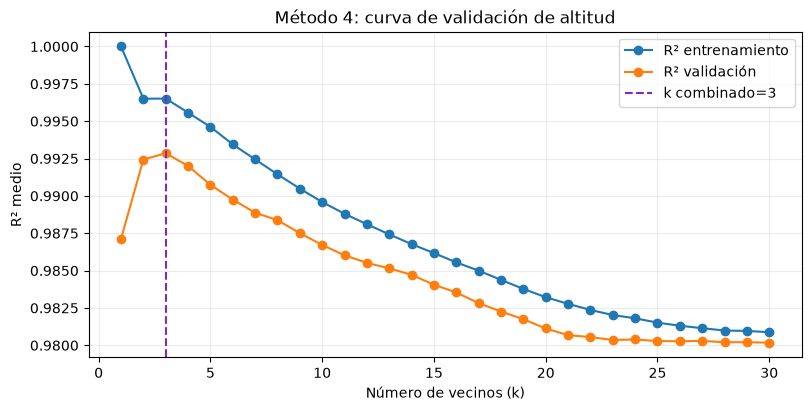

Método 1: k con RMSE mínimo = 3
Selección combinada métodos 1 y 4: k = 3


,k,train_r2,validation_r2,generalization_gap_r2,validation_rmse,within_one_se
0,1,1.000000,0.987125,0.012875,170.706787,False
1,2,0.996503,0.992434,0.004069,130.858587,True
2,3,0.996514,0.992853,0.003661,127.269757,True
3,4,0.995572,0.992003,0.003570,134.330749,False
4,5,0.994617,0.990742,0.003875,144.428438,False
5,6,0.993447,0.989748,0.003699,151.781985,False
6,7,0.992442,0.988875,0.003567,158.034350,False
7,8,0.991445,0.988374,0.003071,161.423500,False
8,9,0.990486,0.987508,0.002978,167.266856,False
9,10,0.989589,0.986715,0.002874,172.548061,False


In [6]:
# Regla combinada reutilizada por altitud y NDVI
def select_k_combining_methods(scores, best_rmse):
    evaluated = scores.copy()
    rmse_limit = best_rmse["validation_rmse"] + best_rmse["validation_rmse_se"]
    evaluated["within_one_se"] = evaluated["validation_rmse"].le(rmse_limit)
    evaluated["generalization_gap_r2"] = (evaluated["train_r2"] - evaluated["validation_r2"]).abs()
    candidates = evaluated.loc[evaluated["within_one_se"]]
    selected = candidates.sort_values(["generalization_gap_r2", "validation_rmse", "k"]).iloc[0]
    return evaluated, selected
# Función gráfica reutilizada por altitud y NDVI en el método 4
def plot_r2_validation_curve(scores, title, selected_k, path):
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(scores["k"], scores["train_r2"], marker="o", label="R² entrenamiento")
    ax.plot(scores["k"], scores["validation_r2"], marker="o", label="R² validación")
    ax.axvline(selected_k, color="#7b2cbf", linestyle="--", label=f"k combinado={selected_k}")
    ax.set(title=title, xlabel="Número de vecinos (k)", ylabel="R² medio")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
altitude_validation, selected_row = select_k_combining_methods(altitude_validation, best_rmse_row)
best_k_altitude = int(selected_row["k"])
plot_r2_validation_curve(altitude_validation, "Método 4: curva de validación de altitud", best_k_altitude, FIG_DIR / "altitude_validation_curve.png")
print(f"Método 1: k con RMSE mínimo = {best_k_method_1}")
print(f"Selección combinada métodos 1 y 4: k = {best_k_altitude}")
display(altitude_validation[["k", "train_r2", "validation_r2", "generalization_gap_r2", "validation_rmse", "within_one_se"]])


### 3. Aplicación KNN

El modelo final se entrena con las celdas completas, imputa sólo valores nulos y propaga la altitud a las 52 semanas de cada `grid_id`.

In [7]:
# Modelo final de altitud con el k elegido por desempeño y generalización
altitude_model = Pipeline([("preprocess", make_preprocessor(ALTITUDE_NUMERIC_PREDICTORS, ALTITUDE_CATEGORICAL_PREDICTORS)), ("knn", KNeighborsRegressor(n_neighbors=best_k_altitude))])
altitude_model.fit(X_altitude, y_altitude) # Entrenamiento del modelo con todas las celdas completas de altitud y predictores
# x_altitude contiene centroides, población y contexto; y_altitude contiene alt_min, alt_mean y alt_max

# Banderas por variable para conservar trazabilidad de las celdas imputadas
# Inicialmente todas se definen como False
altitude_features["alt_min_imputed"] = False
altitude_features["alt_mean_imputed"] = False
altitude_features["alt_max_imputed"] = False
# Identidicación de valores nulos y celdas objetivo para imputación de altitud
altitude_missing_mask = altitude_features[ALTITUDE_COLUMNS].isna()
altitude_target_mask = altitude_missing_mask.any(axis=1) # Celdas que necesitan al menos una variable de altitud
# Predictores de las celdas que necesitan al menos una variable de altitud
altitude_target_features = altitude_features.loc[altitude_target_mask & altitude_features[altitude_feature_columns].notna().all(axis=1), altitude_feature_columns].copy() # Features de las celdas objetivo
if altitude_target_mask.any() and len(altitude_target_features) != int(altitude_target_mask.sum()):
    raise ValueError("Hay celdas de altitud a imputar con predictores incompletos.")
if POPULATION_COLUMNS:
    altitude_target_features[POPULATION_COLUMNS[0]] = np.log1p(altitude_target_features[POPULATION_COLUMNS[0]].astype(float))
# Se rellenan únicamente las variables originalmente ausentes
if not altitude_target_features.empty:
    altitude_predictions = pd.DataFrame(altitude_model.predict(altitude_target_features), index=altitude_target_features.index, columns=ALTITUDE_COLUMNS)
    for column in ALTITUDE_COLUMNS:
        missing_rows = altitude_missing_mask.loc[altitude_target_features.index, column]
        target_indices = altitude_target_features.index[missing_rows]
        altitude_features.loc[target_indices, column] = altitude_predictions.loc[target_indices, column]
        altitude_features.loc[target_indices, f"{column}_imputed"] = True
# Las altitudes estáticas imputadas se propagan a las 52 semanas de cada grid_id
gdf = gdf.merge(altitude_features[["grid_id", *ALTITUDE_COLUMNS, "alt_min_imputed", "alt_mean_imputed", "alt_max_imputed"]], on="grid_id", how="left", suffixes=("", "_static"), validate="many_to_one")
for column in ALTITUDE_COLUMNS:
    gdf[column] = gdf[column].fillna(gdf[f"{column}_static"])
    gdf = gdf.drop(columns=f"{column}_static")
gdf["altitude_imputed_any"] = gdf[[f"{column}_imputed" for column in ALTITUDE_COLUMNS]].any(axis=1)
# Controles posteriores: sin nulos y con relación altitudinal coherente
if gdf[ALTITUDE_COLUMNS].isna().any().any():
    raise ValueError("Persisten nulos de altitud después de imputar.")
if not (gdf["alt_min"] <= gdf["alt_mean"]).all() or not (gdf["alt_mean"] <= gdf["alt_max"]).all():
    raise ValueError("La altitud imputada no cumple alt_min <= alt_mean <= alt_max.")


## Imputación KNN de NDVI

Las cuatro métricas se predicen conjuntamente. `GroupKFold` mantiene todas las semanas de cada `grid_id` en la misma partición; RMSE y R² se evalúan por separado. La selección de `k` puede usar hasta 300 celdas completas, pero el modelo final usa todas las observaciones disponibles.

Los vecinos se definen por posición, estacionalidad, clima, `alt_mean`, población y Köppen.

### 1. Método 1: desempeño según `k`

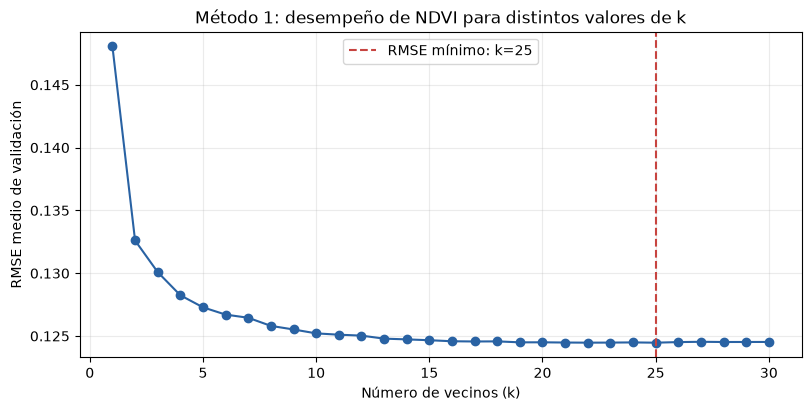

,k,validation_rmse,validation_rmse_se,validation_r2
0,1,0.148053,0.001904,-0.132377
1,2,0.132605,0.002835,-0.028505
2,3,0.130088,0.002204,0.095811
3,4,0.128245,0.002149,0.147138
4,5,0.127285,0.002289,0.177374
5,6,0.126705,0.002333,0.206484
6,7,0.126454,0.002333,0.212795
7,8,0.125807,0.002390,0.223645
8,9,0.125522,0.002363,0.226800
9,10,0.125211,0.002137,0.226731


In [8]:
# Matriz de predictores semanales utilizada para imputar las cuatro métricas NDVI
ndvi_feature_columns = NDVI_NUMERIC_PREDICTORS + NDVI_CATEGORICAL_PREDICTORS
ndvi_features = gdf[ndvi_feature_columns].copy()
if POPULATION_COLUMNS:
    ndvi_features[POPULATION_COLUMNS[0]] = np.log1p(ndvi_features[POPULATION_COLUMNS[0]].astype(float))
# Entrenamiento solo con filas que tienen todas las métricas y predictores completos
ndvi_observed_mask = gdf[NDVI_COLUMNS].notna().all(axis=1)
ndvi_complete_features = ndvi_features.notna().all(axis=1)
ndvi_train_mask = ndvi_observed_mask & ndvi_complete_features
if ndvi_train_mask.sum() < 2:
    raise ValueError("No hay suficientes filas completas para entrenar NDVI.")
X_ndvi_all = ndvi_features.loc[ndvi_train_mask].copy()
y_ndvi_all = gdf.loc[ndvi_train_mask, NDVI_COLUMNS].copy()
# Los grid_id funcionan como grupos para evitar fuga entre semanas de la misma celda
groups_all = gdf.loc[ndvi_train_mask, "grid_id"].reset_index(drop=True)
if groups_all.nunique() < 2:
    raise ValueError("GroupKFold requiere al menos dos grid_id completos para NDVI.")
X_ndvi_cv = X_ndvi_all.reset_index(drop=True)
y_ndvi_cv = y_ndvi_all.reset_index(drop=True)
# La validación se limita a 300 celdas para controlar el costo computacional
if groups_all.nunique() > 300:
    selected_groups = groups_all.drop_duplicates().sample(n=300, random_state=RANDOM_STATE)
    sample_mask = groups_all.isin(selected_groups).to_numpy()
    X_ndvi_cv = X_ndvi_cv.loc[sample_mask].reset_index(drop=True)
    y_ndvi_cv = y_ndvi_cv.loc[sample_mask].reset_index(drop=True)
    groups_cv = groups_all.loc[sample_mask].reset_index(drop=True)
else:
    groups_cv = groups_all
# GroupKFold mantiene todas las semanas de un grid_id en la misma partición
ndvi_splitter = GroupKFold(n_splits=min(CV_FOLDS, groups_cv.nunique()))
ndvi_k_values = candidate_k_values(len(X_ndvi_cv), ndvi_splitter.n_splits)
ndvi_validation = evaluate_kfold(X_ndvi_cv, y_ndvi_cv, NDVI_NUMERIC_PREDICTORS, NDVI_CATEGORICAL_PREDICTORS, ndvi_k_values, ndvi_splitter, groups_cv)
# El método 1 identifica el k con menor RMSE promedio de validación
best_rmse_row_ndvi = ndvi_validation.loc[ndvi_validation["validation_rmse"].idxmin()]
best_k_ndvi_method_1 = int(best_rmse_row_ndvi["k"])
plot_rmse_by_k(ndvi_validation, "Método 1: desempeño de NDVI para distintos valores de k", best_k_ndvi_method_1, FIG_DIR / "ndvi_method_1_k_performance.png")
display(ndvi_validation[["k", "validation_rmse", "validation_rmse_se", "validation_r2"]])


### 2. Método 4: curva de validación

Se comparan las curvas de R² para los `k` cuyo RMSE está dentro de un error estándar del mínimo.

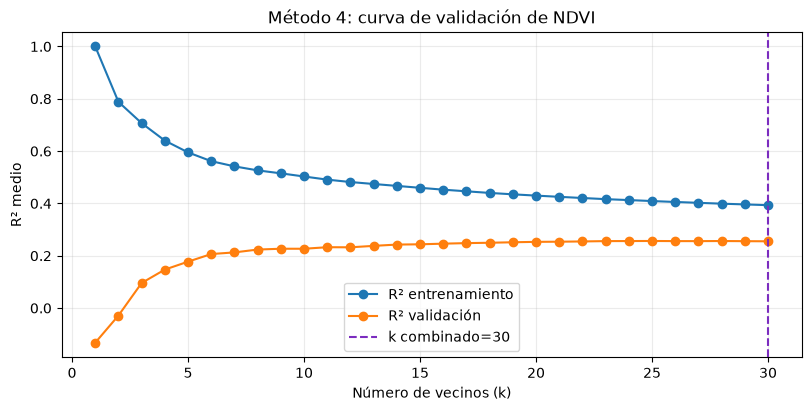

Método 1: k con RMSE mínimo = 25
Selección combinada métodos 1 y 4: k = 30


,k,train_r2,validation_r2,generalization_gap_r2,validation_rmse,within_one_se
0,1,1.000000,-0.132377,1.132377,0.148053,False
1,2,0.788158,-0.028505,0.816663,0.132605,False
2,3,0.706852,0.095811,0.611041,0.130088,False
3,4,0.640106,0.147138,0.492969,0.128245,False
4,5,0.595072,0.177374,0.417698,0.127285,False
5,6,0.561532,0.206484,0.355048,0.126705,False
6,7,0.541663,0.212795,0.328868,0.126454,False
7,8,0.526355,0.223645,0.302710,0.125807,True
8,9,0.515006,0.226800,0.288206,0.125522,True
9,10,0.502972,0.226731,0.276241,0.125211,True


In [9]:
# Aplica la misma regla combinada definida para altitud
ndvi_validation, selected_row_ndvi = select_k_combining_methods(ndvi_validation, best_rmse_row_ndvi)
best_k_ndvi = int(selected_row_ndvi["k"])
plot_r2_validation_curve(ndvi_validation, "Método 4: curva de validación de NDVI", best_k_ndvi, FIG_DIR / "ndvi_validation_curve.png")
print(f"Método 1: k con RMSE mínimo = {best_k_ndvi_method_1}")
print(f"Selección combinada métodos 1 y 4: k = {best_k_ndvi}")
display(ndvi_validation[["k", "train_r2", "validation_r2", "generalization_gap_r2", "validation_rmse", "within_one_se"]])


### 3. Aplicación KNN de NDVI

El modelo final se entrena con las filas completas e imputa sólo valores NDVI nulos.

In [10]:
# Modelo final entrenado con todas las observaciones completas y el k combinado
ndvi_model = Pipeline([("preprocess", make_preprocessor(NDVI_NUMERIC_PREDICTORS, NDVI_CATEGORICAL_PREDICTORS)), ("knn", KNeighborsRegressor(n_neighbors=best_k_ndvi))])
ndvi_model.fit(X_ndvi_all, y_ndvi_all)

# Máscara original para imputar solo valores ausentes y crear banderas de trazabilidad
original_ndvi_nulls = gdf[NDVI_COLUMNS].isna().copy()
ndvi_target_mask = original_ndvi_nulls.any(axis=1)
ndvi_target_features = ndvi_features.loc[ndvi_target_mask & ndvi_complete_features].copy()
if len(ndvi_target_features) != int(ndvi_target_mask.sum()):
    raise ValueError("Hay filas NDVI a imputar con predictores incompletos.")
# Predicción conjunta de las cuatro métricas; solo se reemplazan sus celdas nulas
if not ndvi_target_features.empty:
    ndvi_predictions = pd.DataFrame(ndvi_model.predict(ndvi_target_features), index=ndvi_target_features.index, columns=NDVI_COLUMNS)
    for column in NDVI_COLUMNS:
        missing_rows = original_ndvi_nulls.loc[ndvi_target_features.index, column]
        target_indices = ndvi_target_features.index[missing_rows]
        gdf.loc[target_indices, column] = ndvi_predictions.loc[target_indices, column]

# Banderas permanentes que identifican qué valores fueron imputados
for column, flag in zip(NDVI_COLUMNS, NDVI_IMPUTATION_FLAGS):
    gdf[flag] = original_ndvi_nulls[column]
gdf["ndvi_imputed_any"] = gdf[NDVI_IMPUTATION_FLAGS].any(axis=1)
# Controles posteriores de completitud, rango físico y orden interno
if gdf[NDVI_COLUMNS].isna().any().any():
    raise ValueError("Persisten nulos NDVI después de imputar.")
if ((gdf[NDVI_COLUMNS] < -1) | (gdf[NDVI_COLUMNS] > 1)).any().any():
    raise ValueError("NDVI imputado fuera del rango [-1, 1].")
if not (gdf["ndvi_minimo_bisemanal"] <= gdf["ndvi_media_bisemanal"]).all() or not (gdf["ndvi_media_bisemanal"] <= gdf["ndvi_maximo_bisemanal"]).all():
    raise ValueError("NDVI no cumple ndvi_minimo <= ndvi_media <= ndvi_maximo.")


In [11]:
# Confirma que ninguna observación original haya sido reemplazada por un nulo
for column in ALTITUDE_COLUMNS:
    if (gdf.loc[~gdf[f"{column}_imputed"], column].isna()).any():
        raise ValueError(f"Se perdió un valor observado de {column}.")
for column, flag in zip(NDVI_COLUMNS, NDVI_IMPUTATION_FLAGS):
    if gdf.loc[~gdf[flag], column].isna().any():
        raise ValueError(f"Se perdió un valor observado de {column}.")

# Validación global de variables obligatorias, filas y llaves
mandatory_columns = CLIMATE_COLUMNS + ALTITUDE_COLUMNS + NDVI_COLUMNS
if gdf[mandatory_columns].isna().any().any():
    raise ValueError("Persisten nulos en variables ambientales obligatorias.")
if len(gdf) != len(panel_raw) or not gdf[["grid_id", "year", "epiweek"]].reset_index(drop=True).equals(panel_raw[["grid_id", "year", "epiweek"]].reset_index(drop=True)):
    raise ValueError("Las filas o llaves cambiaron durante la limpieza.")
if gdf.duplicated(["grid_id", "year", "epiweek"]).any():
    raise ValueError("La llave final dejó de ser única.")
print(f"Banderas altitud: {int(gdf['altitude_imputed_any'].sum()):,} filas.")
print(f"Banderas NDVI: {int(gdf['ndvi_imputed_any'].sum()):,} filas.")


Banderas altitud: 260 filas.
Banderas NDVI: 18,976 filas.


## Diagnósticos de vecinos y figuras resumidas

Se guardan tablas de vecinos y figuras para los casos extremos de altitud y las semanas con más imputaciones de NDVI medio.

In [12]:
# Registra, para cada imputación, qué vecinos utilizó KNN y a qué distancia
def build_neighbor_diagnostic(model, X_train, train_frame, X_targets, target_frame, target_labels, block):
    if X_targets.empty:
        return pd.DataFrame(columns=["block", "target_grid_id", "neighbor_grid_id", "neighbor_rank", "knn_distance", "geographic_distance_km", "target_epiweek", "neighbor_epiweek", "variables_imputadas"])
    preprocessor = model.named_steps["preprocess"]
    knn = model.named_steps["knn"]
    # Las distancias KNN se calculan en el espacio transformado del modelo
    transformed_train = preprocessor.transform(X_train)
    transformed_targets = preprocessor.transform(X_targets)
    distances, positions = knn.kneighbors(transformed_targets)
    rows = []
    train_indices = train_frame.index.to_numpy()
    # Una fila diagnóstica por combinación objetivo–vecino
    for target_position, target_index in enumerate(X_targets.index):
        target_row = target_frame.loc[target_index]
        for rank, (distance, position) in enumerate(zip(distances[target_position], positions[target_position]), start=1):
            neighbor_index = train_indices[position]
            neighbor_row = train_frame.loc[neighbor_index]
            rows.append({"block": block, "target_row_index": target_index, "target_grid_id": target_row["grid_id"], "target_epiweek": target_row.get("epiweek", np.nan), "neighbor_grid_id": neighbor_row["grid_id"], "neighbor_epiweek": neighbor_row.get("epiweek", np.nan), "neighbor_rank": rank, "knn_distance": float(distance), "geographic_distance_km": float(np.hypot(target_row["centroid_x_m"] - neighbor_row["centroid_x_m"], target_row["centroid_y_m"] - neighbor_row["centroid_y_m"]) / 1000), "variables_imputadas": target_labels.loc[target_index]})
    return pd.DataFrame(rows)

# Diagnóstico de vecinos usados en la imputación de altitud
altitude_target_indices = altitude_features.index[altitude_target_mask]
altitude_labels = altitude_missing_mask.loc[altitude_target_indices].apply(lambda row: ", ".join(row.index[row].tolist()), axis=1)
altitude_diag_features = altitude_features.loc[altitude_target_indices, altitude_feature_columns].copy()
if POPULATION_COLUMNS:
    altitude_diag_features[POPULATION_COLUMNS[0]] = np.log1p(altitude_diag_features[POPULATION_COLUMNS[0]].astype(float))
altitude_neighbor_diagnostic = build_neighbor_diagnostic(altitude_model, X_altitude, altitude_features, altitude_diag_features, altitude_features, altitude_labels, "altitud")

# Diagnóstico equivalente para las observaciones semanales de NDVI
ndvi_target_indices = ndvi_target_features.index
ndvi_labels = original_ndvi_nulls.loc[ndvi_target_indices].apply(lambda row: ", ".join(row.index[row].tolist()), axis=1)
ndvi_neighbor_diagnostic = build_neighbor_diagnostic(ndvi_model, X_ndvi_all, gdf, ndvi_target_features, gdf, ndvi_labels, "NDVI")

# Resumen compacto de cantidad de pares y distancia geográfica de los vecinos
def neighbor_summary(frame):
    if frame.empty:
        return {"block": frame.get("block", pd.Series(dtype=str)).iloc[0] if not frame.empty else "sin casos", "pares_vecino": 0, "grid_id_objetivo": 0, "distancia_km_mediana": np.nan, "distancia_km_p95": np.nan}
    return {"block": frame["block"].iloc[0], "pares_vecino": len(frame), "grid_id_objetivo": frame["target_grid_id"].nunique(), "distancia_km_mediana": frame["geographic_distance_km"].median(), "distancia_km_p95": frame["geographic_distance_km"].quantile(0.95)}
neighbor_quality = pd.DataFrame([neighbor_summary(altitude_neighbor_diagnostic), neighbor_summary(ndvi_neighbor_diagnostic)])
display(neighbor_quality)


,block,pares_vecino,grid_id_objetivo,distancia_km_mediana,distancia_km_p95
0,altitud,15,5,5.794736,86.726034
1,NDVI,569280,3210,39.439406,110.893918


### Altitud: tres casos extremos de selección de vecinos

Se muestran los tres `grid_id` imputados con mayor distancia geográfica máxima a sus vecinos. La distancia KNN también incorpora los demás predictores transformados.

,target_row_index,target_grid_id,distancia_max_km,distancia_mediana_km,n_vecinos
3,3306,3359,3.476128,1.947762,3
4,3339,3392,1.773005,1.655100,3
1,2456,2509,1.744417,1.630940,3


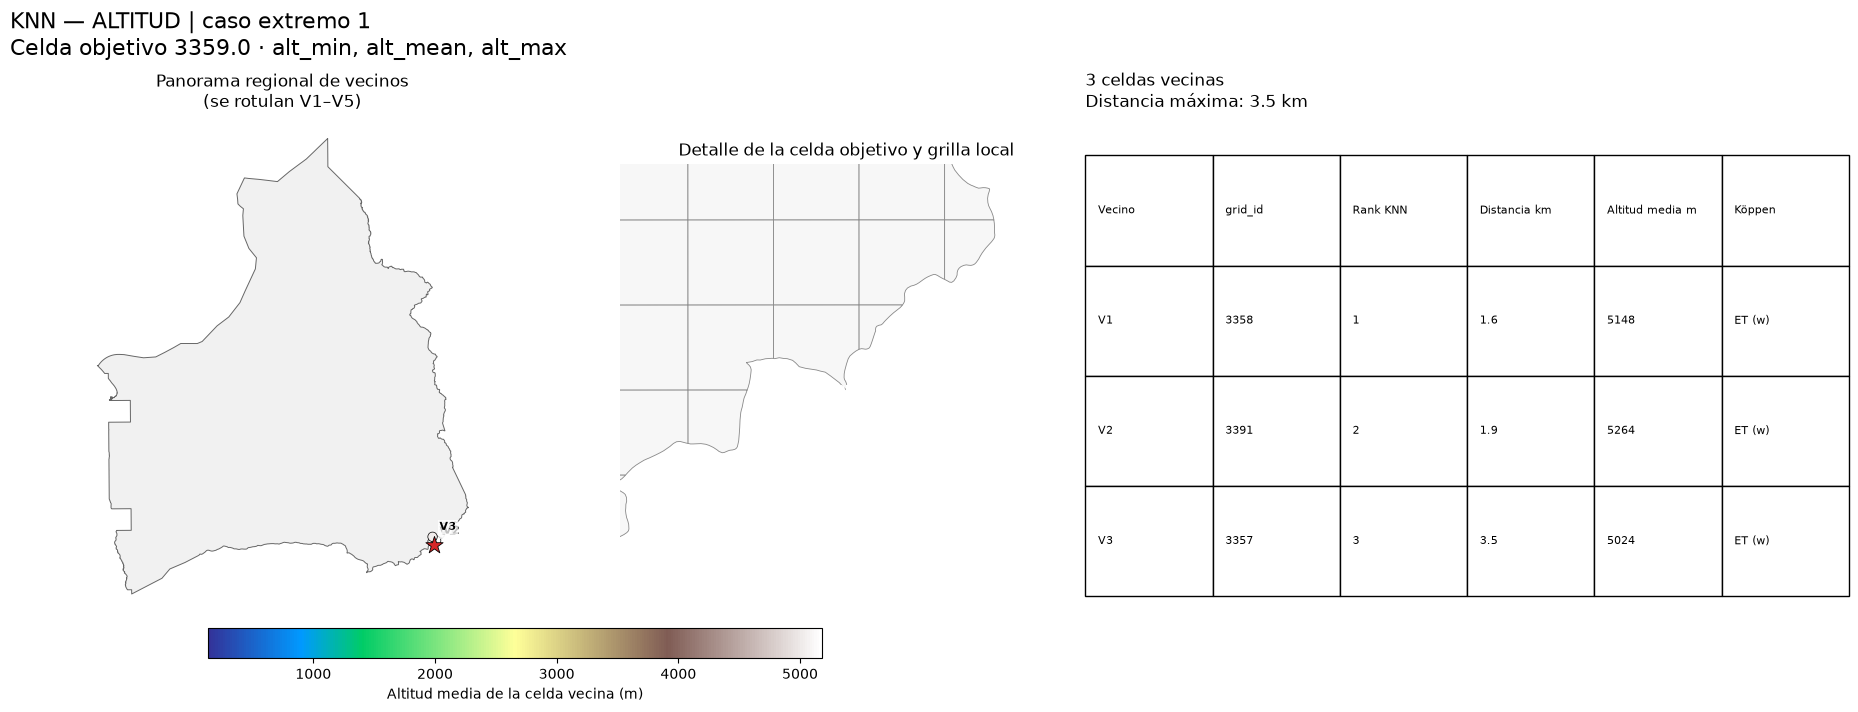

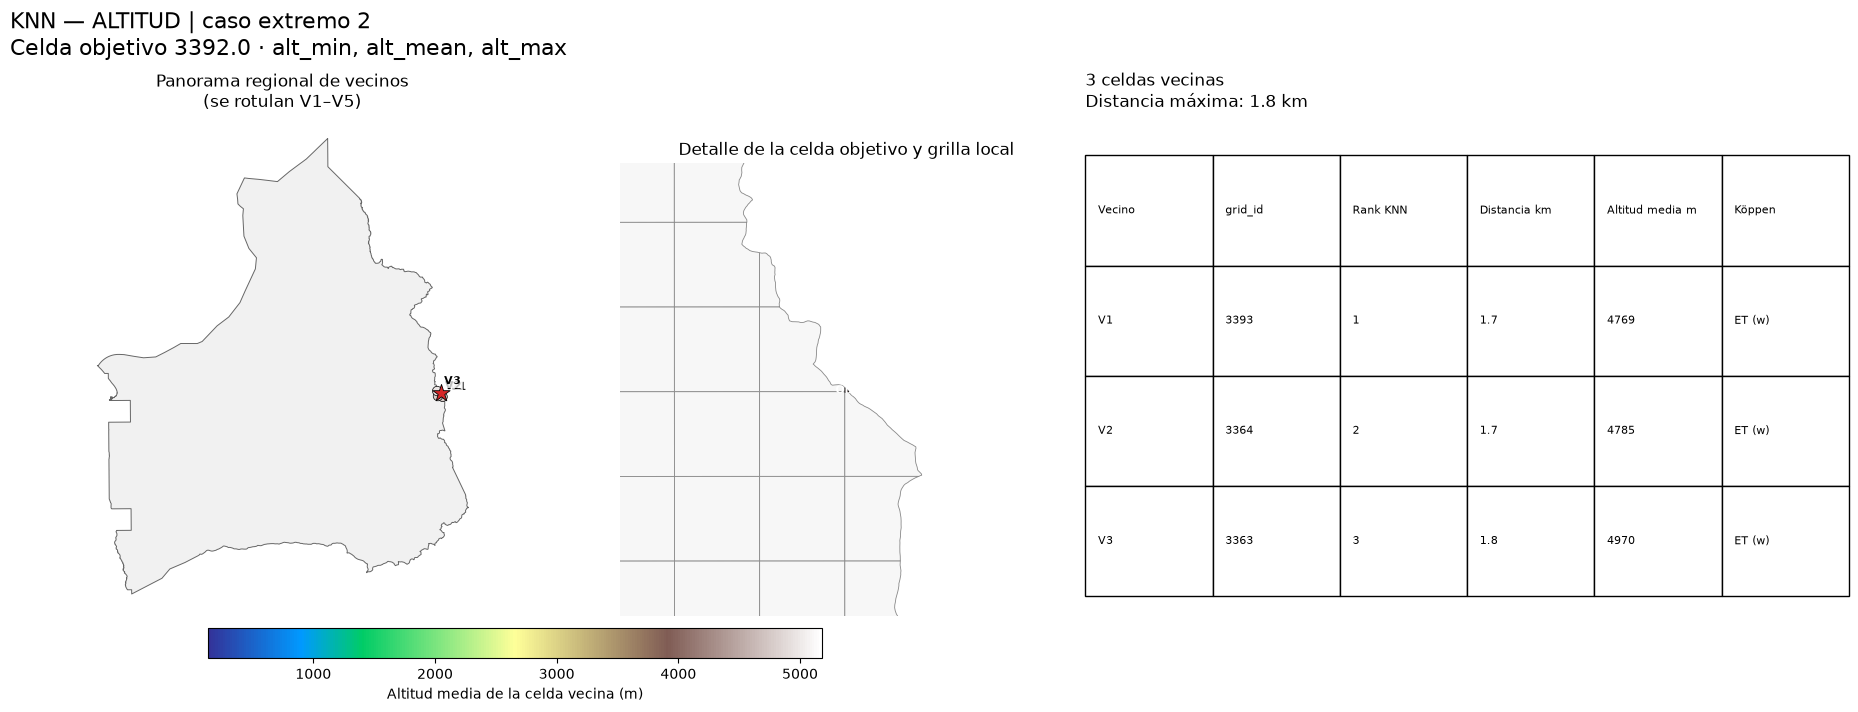

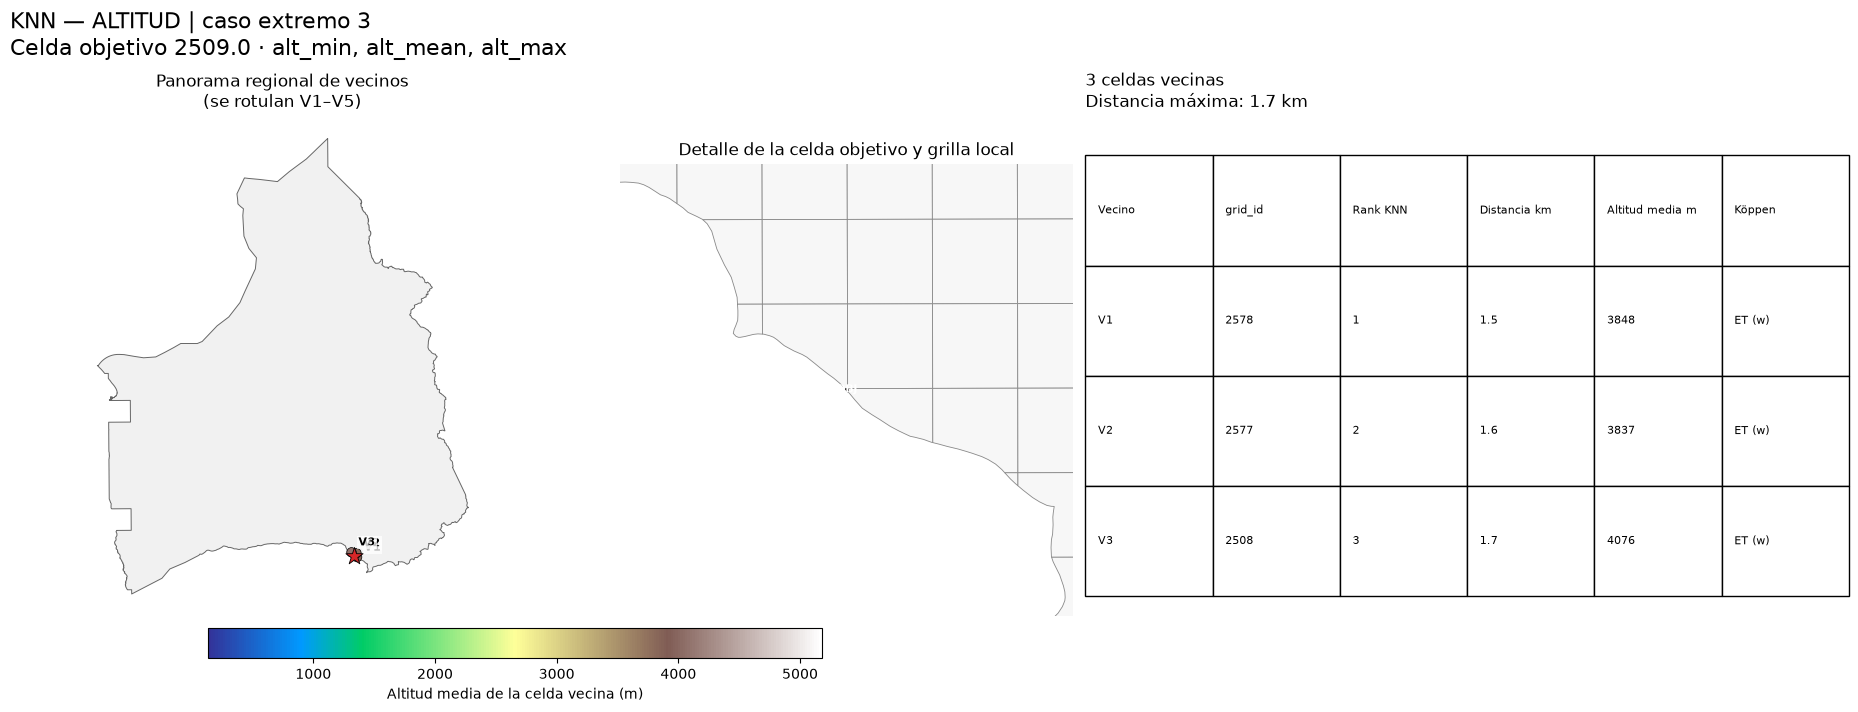

Figuras extremas de altitud:
- C:\tesis_aedes_grilla_2024\outputs\figures\knn_experiments\altitude_extreme_neighbors_01_grid_3359.0.png
- C:\tesis_aedes_grilla_2024\outputs\figures\knn_experiments\altitude_extreme_neighbors_02_grid_3392.0.png
- C:\tesis_aedes_grilla_2024\outputs\figures\knn_experiments\altitude_extreme_neighbors_03_grid_2509.0.png


In [13]:
# Reconstruye los vecinos reales del modelo para las figuras extremas
altitude_figure_rows = []
if not altitude_diag_features.empty: # Solo si hay celdas de altitud a imputar
    transformed_targets = altitude_model.named_steps["preprocess"].transform(altitude_diag_features) # Transformación de predictores de celdas objetivo
    knn_distances, neighbor_positions = altitude_model.named_steps["knn"].kneighbors(transformed_targets)
    altitude_train_indices = X_altitude.index.to_numpy()
    for target_position, target_index in enumerate(altitude_diag_features.index):
        target_row = altitude_features.loc[target_index]
        for rank, (knn_distance, neighbor_position) in enumerate(zip(knn_distances[target_position], neighbor_positions[target_position]), start=1):
            neighbor_index = altitude_train_indices[neighbor_position]
            neighbor_row = altitude_features.loc[neighbor_index]
            geographic_distance_km = np.hypot(target_row["centroid_x_m"] - neighbor_row["centroid_x_m"], target_row["centroid_y_m"] - neighbor_row["centroid_y_m"]) / 1000
            altitude_figure_rows.append({
                "target_row_index": target_index,
                "target_grid_id": target_row["grid_id"],
                "neighbor_grid_id": neighbor_row["grid_id"],
                "neighbor_rank": rank,
                "knn_distance": float(knn_distance),
                "geographic_distance_km": float(geographic_distance_km),
                "variables_imputadas": altitude_labels.loc[target_index],
            })
altitude_figure_diagnostic = pd.DataFrame(altitude_figure_rows, columns=["target_row_index", "target_grid_id", "neighbor_grid_id", "neighbor_rank", "knn_distance", "geographic_distance_km", "variables_imputadas"])

# Contexto espacial de una fila por celda para representar objetivo y vecinos
altitude_map_context = (
    grid_geometry[["grid_id", "geometry"]]
    .merge(
        gdf[["grid_id", "alt_mean", "koppen_fin"]].drop_duplicates("grid_id"),
        on="grid_id",
        how="left",
        validate="one_to_one",
    )
    .to_crs(METRIC_CRS)
    .set_index("grid_id", drop=False)
)
altitude_map_context["centroid_x_m"] = altitude_map_context.geometry.centroid.x
altitude_map_context["centroid_y_m"] = altitude_map_context.geometry.centroid.y
altitude_region_outline = altitude_map_context[["geometry"]].dissolve()
altitude_norm = Normalize(
    vmin=altitude_map_context["alt_mean"].quantile(0.01),
    vmax=altitude_map_context["alt_mean"].quantile(0.99),
)
# Casos con los vecinos geográficamente más distantes
altitude_extreme_cases = (
    altitude_figure_diagnostic
    .groupby(["target_row_index", "target_grid_id"], as_index=False)
    .agg(
        distancia_max_km=("geographic_distance_km", "max"),
        distancia_mediana_km=("geographic_distance_km", "median"),
        n_vecinos=("neighbor_grid_id", "nunique"),
    )
    .sort_values("distancia_max_km", ascending=False)
    .head(3)
)
display(HTML("<h4>Casos extremos de altitud seleccionados</h4><p>Ordenados por la mayor distancia geográfica registrada entre la celda objetivo y sus vecinos KNN.</p>"))
display(altitude_extreme_cases)

def plot_altitude_extreme_neighbors(selected_case, case_number):
    # Recupera todos los vecinos utilizados para esta celda objetivo
    case = altitude_figure_diagnostic.loc[
        altitude_figure_diagnostic["target_row_index"].eq(selected_case["target_row_index"])
    ].sort_values("neighbor_rank")
    target_grid_id = selected_case["target_grid_id"]
    target = altitude_map_context.loc[[target_grid_id]]
    target_point = target.geometry.centroid.iloc[0]
    # Una fila por celda vecina con rango, distancia, altitud y Köppen
    neighbors = (
        case.groupby("neighbor_grid_id", as_index=False)
        .agg(
            rank_knn=("neighbor_rank", "min"),
            distancia_km=("geographic_distance_km", "max"),
        )
        .merge(
            altitude_map_context[["grid_id", "alt_mean", "koppen_fin", "centroid_x_m", "centroid_y_m"]].reset_index(drop=True),
            left_on="neighbor_grid_id",
            right_on="grid_id",
            how="left",
            validate="one_to_one",
        )
        .sort_values("rank_knn")
        .reset_index(drop=True)
    )
    neighbors["etiqueta"] = [f"V{i}" for i in range(1, len(neighbors) + 1)]
    # Composición equivalente a la figura histórica: panorama, detalle y tabla
    fig = plt.figure(figsize=(19, 7), constrained_layout=True)
    layout = fig.add_gridspec(1, 3, width_ratios=[1.15, 0.8, 1.35])
    overview_ax = fig.add_subplot(layout[0, 0])
    zoom_ax = fig.add_subplot(layout[0, 1])
    table_ax = fig.add_subplot(layout[0, 2])
    altitude_region_outline.plot(ax=overview_ax, facecolor="#f1f1f1", edgecolor="#666666", linewidth=0.7)
    for neighbor in neighbors.itertuples(index=False):
        overview_ax.plot([target_point.x, neighbor.centroid_x_m], [target_point.y, neighbor.centroid_y_m], color="#777777", linewidth=0.8, alpha=0.5)
    overview_ax.scatter(neighbors["centroid_x_m"], neighbors["centroid_y_m"], c=neighbors["alt_mean"], cmap="terrain", norm=altitude_norm, s=46, edgecolor="black", linewidth=0.5, zorder=3)
    overview_ax.scatter(target_point.x, target_point.y, marker="*", s=170, color="#d62728", edgecolor="black", linewidth=0.6, zorder=4)
    for neighbor in neighbors.head(5).itertuples(index=False):
        overview_ax.annotate(neighbor.etiqueta, (neighbor.centroid_x_m, neighbor.centroid_y_m), xytext=(5, 5), textcoords="offset points", fontsize=8, fontweight="bold", bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none", "pad": 1})
    overview_ax.set_title("Panorama regional de vecinos\n(se rotulan V1–V5)")
    overview_ax.set_axis_off()
    # Detalle de la grilla alrededor de la celda objetivo
    xmin, ymin, xmax, ymax = target.total_bounds
    margin = max(6000, 4 * max(xmax - xmin, ymax - ymin))
    local = altitude_map_context.cx[xmin - margin:xmax + margin, ymin - margin:ymax + margin]
    local.plot(ax=zoom_ax, facecolor="#f7f7f7", edgecolor="#888888", linewidth=0.6)
    target.plot(ax=zoom_ax, facecolor="#d62728", edgecolor="black", linewidth=1.2, alpha=0.85)
    zoom_ax.text(target_point.x, target_point.y, "OBJ", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    zoom_ax.set_xlim(xmin - margin, xmax + margin)
    zoom_ax.set_ylim(ymin - margin, ymax + margin)
    zoom_ax.set_title("Detalle de la celda objetivo y grilla local")
    zoom_ax.set_axis_off()
    # Tabla compacta de los vecinos efectivamente usados
    table_data = pd.DataFrame({
        "Vecino": neighbors["etiqueta"],
        "grid_id": neighbors["neighbor_grid_id"],
        "Rank KNN": neighbors["rank_knn"],
        "Distancia km": neighbors["distancia_km"].round(1),
        "Altitud media m": neighbors["alt_mean"].round(0).astype("Int64"),
        "Köppen": neighbors["koppen_fin"],
    })
    table_ax.set_axis_off()
    table_ax.set_title(f"{len(neighbors)} celdas vecinas\nDistancia máxima: {selected_case['distancia_max_km']:.1f} km", loc="left")
    table = table_ax.table(cellText=table_data.values, colLabels=table_data.columns, cellLoc="left", colLoc="left", loc="upper left", bbox=[0, 0.04, 1, 0.88])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.3)
    variables = case["variables_imputadas"].iloc[0]
    fig.suptitle(f"KNN — ALTITUD | caso extremo {case_number}\nCelda objetivo {target_grid_id} · {variables}", fontsize=16, x=0.03, ha="left")
    fig.colorbar(ScalarMappable(norm=altitude_norm, cmap="terrain"), ax=[overview_ax, zoom_ax], orientation="horizontal", shrink=0.55, pad=0.02, label="Altitud media de la celda vecina (m)")
    output_path = FIG_DIR / f"altitude_extreme_neighbors_{case_number:02d}_grid_{target_grid_id}.png"
    fig.savefig(output_path, dpi=190, bbox_inches="tight")
    plt.show()
    return output_path

altitude_extreme_map_paths = [
    plot_altitude_extreme_neighbors(case, number)
    for number, (_, case) in enumerate(altitude_extreme_cases.iterrows(), start=1)
]
print("Figuras extremas de altitud:")
for path in altitude_extreme_map_paths:
    print(f"- {path}")


### NDVI: tres semanas con más celdas originalmente nulas

Se comparan valores observados e imputados en las tres semanas con más nulos originales de `ndvi_media_bisemanal`.

,epiweek,celdas_originalmente_nulas
7,8,2956
8,9,2847
9,10,2847


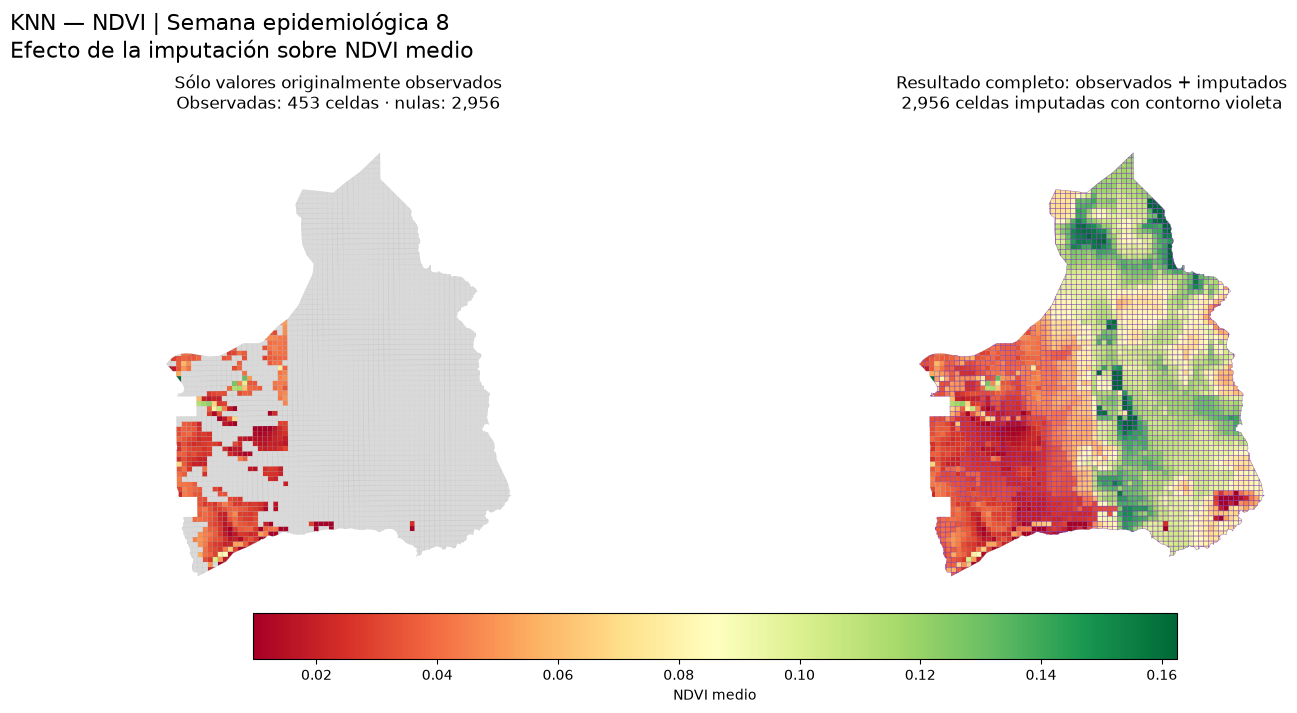

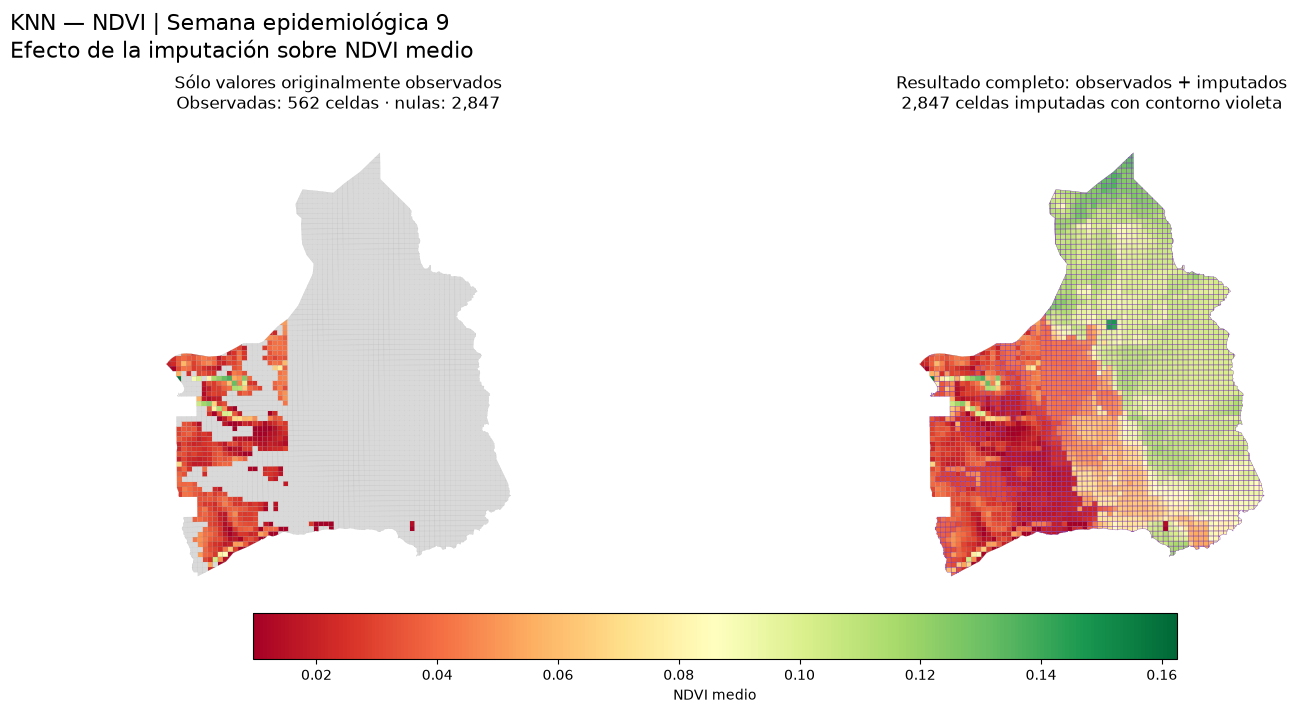

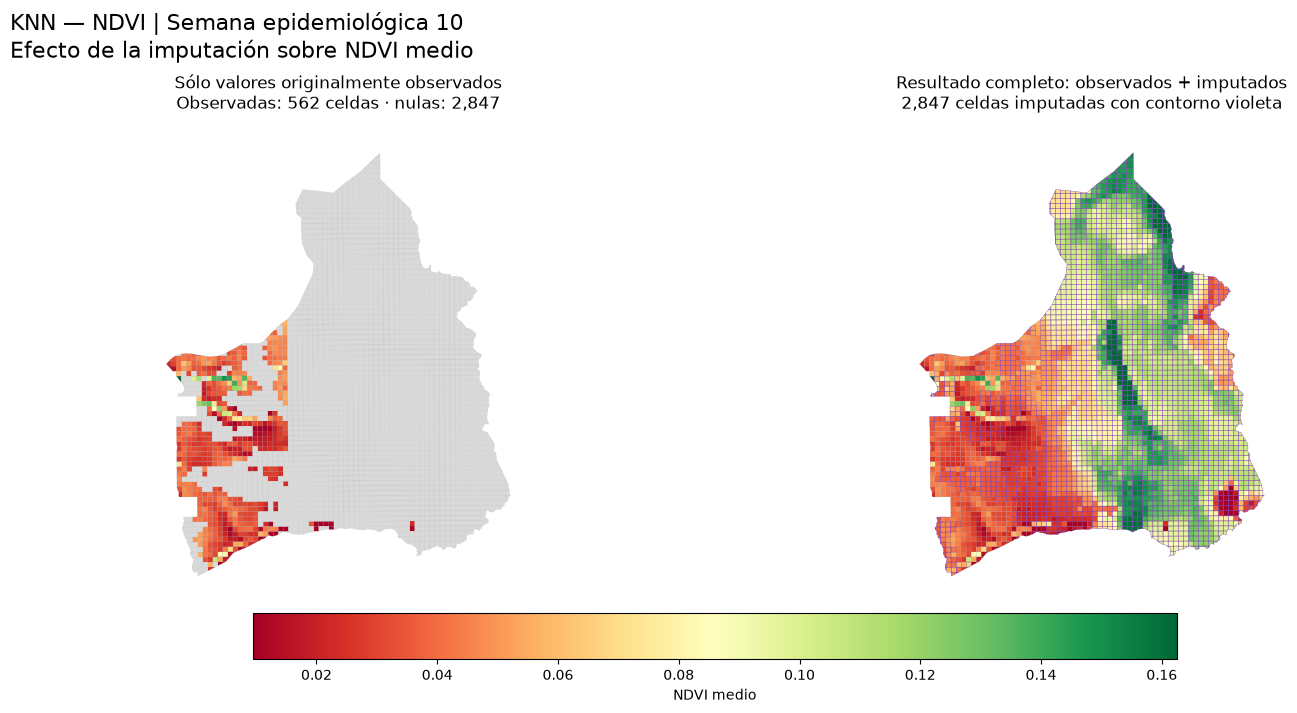

Figuras prioritarias de NDVI:
- C:\tesis_aedes_grilla_2024\outputs\figures\knn_experiments\ndvi_media_week_08_observed_vs_imputed.png
- C:\tesis_aedes_grilla_2024\outputs\figures\knn_experiments\ndvi_media_week_09_observed_vs_imputed.png
- C:\tesis_aedes_grilla_2024\outputs\figures\knn_experiments\ndvi_media_week_10_observed_vs_imputed.png


In [14]:
NDVI_MAP_COLUMN = "ndvi_media_bisemanal"
NDVI_MAP_FLAG = "ndvi_media_bisemanal_imputed"
# Ranking de semanas según la cantidad de celdas originalmente nulas
ndvi_priority_weeks = (
    gdf.groupby("epiweek", as_index=False)[NDVI_MAP_FLAG]
    .sum()
    .rename(columns={NDVI_MAP_FLAG: "celdas_originalmente_nulas"})
    .sort_values(["celdas_originalmente_nulas", "epiweek"], ascending=[False, True])
    .head(3)
)
display(HTML("<h4>Semanas seleccionadas para los mapas NDVI</h4><p>Se priorizan las semanas con más celdas originalmente nulas en NDVI medio.</p>"))
display(ndvi_priority_weeks)
selected_ndvi_weeks = ndvi_priority_weeks["epiweek"].astype(int).tolist()
# Una escala común permite comparar directamente las tres semanas
ndvi_map_values = gdf.loc[gdf["epiweek"].isin(selected_ndvi_weeks), NDVI_MAP_COLUMN].dropna()
ndvi_vmin = ndvi_map_values.quantile(0.01)
ndvi_vmax = ndvi_map_values.quantile(0.99)
if np.isclose(ndvi_vmin, ndvi_vmax):
    ndvi_vmax = ndvi_vmin + 1e-9
ndvi_map_norm = Normalize(vmin=ndvi_vmin, vmax=ndvi_vmax)

def plot_ndvi_observed_vs_imputed(week):
    frame = gdf.loc[gdf["epiweek"].eq(week)].drop_duplicates("grid_id").to_crs(METRIC_CRS).copy()
    imputed_mask = frame[NDVI_MAP_FLAG]
    observed_only = frame.copy()
    observed_only.loc[imputed_mask, NDVI_MAP_COLUMN] = np.nan
    fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
    observed_only.plot(
        ax=axes[0], column=NDVI_MAP_COLUMN, cmap="RdYlGn", norm=ndvi_map_norm,
        edgecolor="#777777", linewidth=0.08,
        missing_kwds={"color": "#d9d9d9", "edgecolor": "#aaaaaa", "linewidth": 0.08},
    )
    axes[0].set_title("Sólo valores originalmente observados\n" f"Observadas: {(~imputed_mask).sum():,} celdas · nulas: {imputed_mask.sum():,}")
    frame.plot(ax=axes[1], column=NDVI_MAP_COLUMN, cmap="RdYlGn", norm=ndvi_map_norm, edgecolor="#777777", linewidth=0.08)
    if imputed_mask.any():
        frame.loc[imputed_mask].boundary.plot(ax=axes[1], color="#7b2cbf", linewidth=0.25, alpha=0.75)
    axes[1].set_title("Resultado completo: observados + imputados\n" f"{imputed_mask.sum():,} celdas imputadas con contorno violeta")
    for ax in axes:
        ax.set_axis_off()
    fig.colorbar(ScalarMappable(norm=ndvi_map_norm, cmap="RdYlGn"), ax=axes.tolist(), orientation="horizontal", shrink=0.62, pad=0.03, label="NDVI medio")
    fig.suptitle(f"KNN — NDVI | Semana epidemiológica {week}\nEfecto de la imputación sobre NDVI medio", fontsize=16, x=0.03, ha="left")
    output_path = FIG_DIR / f"ndvi_media_week_{week:02d}_observed_vs_imputed.png"
    fig.savefig(output_path, dpi=190, bbox_inches="tight")
    plt.show()
    return output_path

ndvi_priority_map_paths = [plot_ndvi_observed_vs_imputed(week) for week in selected_ndvi_weeks]
print("Figuras prioritarias de NDVI:")
for path in ndvi_priority_map_paths:
    print(f"- {path}")


## Producto limpio y diagnósticos canónicos

El panel limpio conserva llaves y variables para EDA y modelamiento. Las banderas quedan en el panel de control; las tablas de vecinos se guardan por separado.

In [15]:
# Banderas que documentan qué valores fueron completados por KNN
PANEL_KEY = ["grid_id", "year", "epiweek"]
ALTITUDE_IMPUTATION_FLAGS = [f"{column}_imputed" for column in ALTITUDE_COLUMNS]
IMPUTATION_FLAG_COLUMNS = [
    *ALTITUDE_IMPUTATION_FLAGS,
    "altitude_imputed_any",
    *NDVI_IMPUTATION_FLAGS,
    "ndvi_imputed_any",
]
imputation_flags = gdf[PANEL_KEY + IMPUTATION_FLAG_COLUMNS].copy()
altitude_imputed_rows = int(gdf["altitude_imputed_any"].sum())
ndvi_imputed_rows = int(gdf["ndvi_imputed_any"].sum())

# Actualiza el panel de control sin duplicar banderas de ejecuciones anteriores
quality_check = pd.read_parquet(ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH)
quality_check = quality_check.drop(columns=IMPUTATION_FLAG_COLUMNS, errors="ignore").merge(
    imputation_flags,
    on=PANEL_KEY,
    how="left",
    validate="one_to_one",
)

# El panel ambiental final excluye geometría, auxiliares y banderas diagnósticas
territorial_columns = [column for column in gdf.columns if column.casefold().startswith(("distr", "comun"))]
clean = gdf.drop(columns=["geometry", "centroid_x_m", "centroid_y_m", *territorial_columns, *IMPUTATION_FLAG_COLUMNS], errors="ignore").copy()
if "geometry" in clean.columns or any(column in clean.columns for column in territorial_columns):
    raise ValueError("El producto limpio conserva columnas no permitidas.")
if len(clean) != len(panel_raw):
    raise ValueError("El producto limpio perdió filas.")
if not clean[PANEL_KEY].equals(panel_raw[PANEL_KEY]):
    raise ValueError("El producto limpio alteró las llaves.")

# Creación de carpetas y guardado del panel limpio y diagnósticos de vecinos
ENVIRONMENT_GRID_WEEK_CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
DIAGNOSTICS_KNN_ALTITUDE_PATH.parent.mkdir(parents=True, exist_ok=True)
clean.to_parquet(ENVIRONMENT_GRID_WEEK_CLEAN_PATH, index=False)
quality_check.to_parquet(ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH, index=False)
altitude_neighbor_diagnostic.to_parquet(DIAGNOSTICS_KNN_ALTITUDE_PATH, index=False)
ndvi_neighbor_diagnostic.to_parquet(DIAGNOSTICS_KNN_NDVI_PATH, index=False)
print(f"Producto limpio: {ENVIRONMENT_GRID_WEEK_CLEAN_PATH}")
print(f"Control de calidad actualizado: {ENVIRONMENT_GRID_WEEK_QUALITY_CHECK_PATH}")
print(f"Diagnóstico altitud: {DIAGNOSTICS_KNN_ALTITUDE_PATH}")
print(f"Diagnóstico NDVI: {DIAGNOSTICS_KNN_NDVI_PATH}")

# Vista del mismo DataFrame que se acaba de guardar como parquet final
display(HTML("<h4>Vista del panel ambiental limpio</h4><p>Primeras diez filas; use el desplazamiento horizontal para revisar todas las columnas.</p><div style='overflow-x:auto'>" + clean.head(10).to_html(index=False, max_cols=None) + "</div>"))
# Inventario ordenado de las columnas incluidas en el producto final
final_column_inventory = pd.DataFrame({
    "posición": np.arange(1, len(clean.columns) + 1),
    "columna": clean.columns,
    "tipo": [str(clean[column].dtype) for column in clean.columns],
})
display(HTML("<h4>Listado de columnas del panel ambiental limpio</h4><p>El orden corresponde al parquet guardado.</p>"))
display(final_column_inventory)


Producto limpio: C:\tesis_aedes_grilla_2024\data\processed\environment\environment_grid_week_2024_clean.parquet
Control de calidad actualizado: C:\tesis_aedes_grilla_2024\data\interim\environment\quality_check_environment_grid_week_2024_raw.parquet
Diagnóstico altitud: C:\tesis_aedes_grilla_2024\data\diagnostics\diagnostico_vecinos_knn_altura.parquet
Diagnóstico NDVI: C:\tesis_aedes_grilla_2024\data\diagnostics\diagnostico_vecinos_knn_ndvi.parquet


grid_id,year,epiweek,tmean_c,tmin_c,tmax_c,alt_min,alt_mean,alt_max,rh_mean,rh_min,rh_max,tp_sum,koppen_fin,population,ndvi_media_bisemanal,ndvi_maximo_bisemanal,ndvi_minimo_bisemanal,ndvi_desvest_bisemanal,epiweek_sin,epiweek_cos
0,2024,1,21.209301,19.992899,22.276896,25.0,33.596774,43.0,74.356583,71.468781,76.885185,0.016606,BWh,0.0,0.050019,0.081831,-0.021624,0.004055,0.120537,0.992709
0,2024,2,22.054096,21.573660,22.765982,25.0,33.596774,43.0,73.982315,71.317276,76.284805,0.011030,BWh,0.0,0.048979,0.080882,-0.004966,0.003381,0.239316,0.970942
0,2024,3,22.568083,22.038534,23.052988,25.0,33.596774,43.0,75.665398,72.660240,78.163437,0.068585,BWh,0.0,0.047940,0.079934,0.011691,0.002707,0.354605,0.935016
0,2024,4,23.774378,23.398520,24.111084,25.0,33.596774,43.0,72.535446,70.525070,74.601913,0.008243,BWh,0.0,0.043426,0.070744,0.004822,0.001353,0.464723,0.885456
0,2024,5,22.861515,22.499634,23.158884,25.0,33.596774,43.0,73.460915,72.232567,74.605240,0.005395,BWh,0.0,0.038912,0.061555,-0.002047,0.000000,0.568065,0.822984
0,2024,6,25.018829,24.110687,25.648270,25.0,33.596774,43.0,71.713272,67.142258,77.242050,0.005812,BWh,0.0,0.028242,0.242594,-0.162309,0.000676,0.663123,0.748511
0,2024,7,23.730053,23.066925,24.236368,25.0,33.596774,43.0,75.282051,71.676620,81.074158,0.052671,BWh,0.0,0.033400,0.316837,-0.140295,0.000000,0.748511,0.663123
0,2024,8,24.646017,23.532104,25.408484,25.0,33.596774,43.0,76.529297,72.132515,81.423096,0.047258,BWh,0.0,0.032289,0.323296,-0.150157,0.000000,0.822984,0.568065
0,2024,9,23.541357,22.868347,24.530279,25.0,33.596774,43.0,75.064690,73.228439,77.841995,0.171275,BWh,0.0,0.027595,0.062425,-0.020239,0.000000,0.885456,0.464723
0,2024,10,23.356249,22.439676,24.117676,25.0,33.596774,43.0,74.060120,72.234764,77.018234,0.004876,BWh,0.0,0.037177,0.069368,-0.017917,0.003663,0.935016,0.354605


,posición,columna,tipo
0,1,grid_id,int64
1,2,year,Int64
2,3,epiweek,Int64
3,4,tmean_c,float64
4,5,tmin_c,float64
5,6,tmax_c,float64
6,7,alt_min,float64
7,8,alt_mean,float64
8,9,alt_max,float64
9,10,rh_mean,float64


## Conclusión reproducible

Se informa la selección de `k`, la calidad de los vecinos, la magnitud de las imputaciones y los nulos restantes.

In [16]:
# Resumen final de dimensiones e imputaciones realizadas
print(f"Filas finales: {len(clean):,}")
print(f"Grid_id: {clean['grid_id'].nunique():,}; semanas por grid_id: {clean.groupby('grid_id').size().unique().tolist()}")
print(f"Filas con alguna imputación de altitud: {altitude_imputed_rows:,}")
print(f"Filas con alguna imputación NDVI: {ndvi_imputed_rows:,}")
# Conteo de nulos calculado sobre el mismo DataFrame guardado como environment final
final_null_report = pd.DataFrame({
    "variable": clean.columns,
    "n_nulos": clean.isna().sum().to_numpy(),
    "pct_nulos": (100 * clean.isna().mean()).round(3).to_numpy(),
})
print(f"Nulos totales en environment final: {int(final_null_report['n_nulos'].sum()):,}")
print(f"Filas con al menos un nulo: {int(clean.isna().any(axis=1).sum()):,}")
display(final_null_report)
print("Variables que requieren revisión en data_cleaning: cualquier nulo residual de contexto/población y la sensibilidad del método KNN.")


Filas finales: 177,268
Grid_id: 3,409; semanas por grid_id: [52]
Filas con alguna imputación de altitud: 260
Filas con alguna imputación NDVI: 18,976
Nulos totales en environment final: 0
Filas con al menos un nulo: 0


,variable,n_nulos,pct_nulos
0,grid_id,0,0.0
1,year,0,0.0
2,epiweek,0,0.0
3,tmean_c,0,0.0
4,tmin_c,0,0.0
5,tmax_c,0,0.0
6,alt_min,0,0.0
7,alt_mean,0,0.0
8,alt_max,0,0.0
9,rh_mean,0,0.0


Variables que requieren revisión en data_cleaning: cualquier nulo residual de contexto/población y la sensibilidad del método KNN.
